### Phase vs. amplitude encoding in the whole-brain Stuart–Landau model

This notebook reproduces **Figure 4** by simulating a 29-area whole-brain network of Stuart–Landau oscillators (Markov et al. 2014 structural connectivity) and computing pairwise and higher-order (2-plet / 3-plet) PID across edges.

**Workflow:**
1. Configure environment and imports.
2. Load anatomical connectivity (FLN matrix, hierarchy, cortical area positions).
3. Set up simulation parameters and the Gaussian coupling profile.
4. Run the trial-wise simulation and store results.
5. Compute pairwise MI (amplitude vs. phase) for each area pair.
6. Compute higher-order redundancy and synergy across edge-pairs (2-plets and 3-plets).
7. Assemble and export the figure.

#### 1) Environment setup

In [ ]:
import os
import sys

# add project root to path so `from src.models import simulate` resolves
sys.path.insert(1, os.path.join("/", *os.getcwd().split("/")[:-1]))


In [ ]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import plot
import xarray as xr
from hoi.core import get_mi
from tqdm import tqdm

from src.models import simulate


In [ ]:
# force JAX to run on CPU (avoids GPU memory issues for this workload)
jax.config.update("jax_platform_name", "cpu")


In [4]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 2) Anatomical data — Markov et al. (2014)

Load the 29-area macaque FLN (fraction of labelled neurons) matrix and cortical hierarchy values. `xy` contains 2-D pixel coordinates for each area on the flatmap used in Panel A. `sel_area_names` is the 7-area subset for higher-order analysis.

In [ ]:
# 29 macaque cortical areas from Markov et al. (2014), in connectivity-matrix order
area_names = [
    "V1",   "V2",   "V4",   "DP",   "MT",   "8m",   "5",    "8l",   "TEO",  "2",
    "F1",   "STPc", "7A",   "46d",  "10",   "9/46v","9/46d","F5",   "TEpd", "PBr",
    "7m",   "7B",   "F2",   "STPi", "PROm", "F7",   "8B",   "STPr", "24c",
]


In [ ]:
# 2-D pixel coordinates of each area on the macaque cortical flatmap (Panel A)
xy = [
    (40,  364), (76,  298), (112, 367), (145, 161), (166, 319),
    (475, 194), (245, 146), (455, 209), (118, 449), (279, 300),
    (329, 124), (171, 300), (173, 142), (604, 206), (689, 263),
    (497, 248), (524, 206), (396, 309), (221, 533), (265, 413),
    (243, 100), (213, 239), (486, 82),  (247, 435), (423, 397),
    (585, 134), (604, 147), (335, 489), (555, 191),
]


In [ ]:
# 7-area subset used for higher-order (2-plet / 3-plet) PID analysis
sel_area_names = ["V1", "V2", "V4", "8m", "7A", "9/46d", "24c"]


In [8]:
data = np.load("../interareal/markov2014.npy", allow_pickle=True).item()

Nareas = 29
flnMat = data["FLN"]                    # FLN[i,j]: fraction of neurons projecting from j to i
h = np.squeeze(data["Hierarchy"].T)     # cortical hierarchy index per area

eta = 0  # hierarchy scaling disabled (set > 0 to weight FLN by hierarchy gradient)

#### 3) Simulation parameters and coupling profile

Same Gaussian profile as Figure 3 (8 carrier cycles wide, 0–0.4 s). External input is injected only into area 0 (V1); all other areas receive indirect drive through the FLN connectivity.

In [ ]:
ntrials = 1000
dt = 1e-4
fsamp = 1 / dt            # 10 kHz
time = np.arange(-4, 2, 1 / fsamp)
beta = 1e-4               # noise amplitude
Npoints = len(time)
decim = 20                # 10 kHz → 500 Hz after decimation
f = 40                    # Hz, carrier frequency (same for all 29 nodes)

# weight FLN by hierarchy gradient; eta=0 leaves FLN unchanged
flnMat = (1 + eta * h)[:, np.newaxis] * flnMat


In [ ]:
# Gaussian envelope width: 8 carrier cycles converted to seconds
s = 8 / (2 * np.pi * f)

# build unit Gaussian pulse over the stimulus window [0, 0.4] s
time_start, time_end = 0, 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian

# coupling strength linearly varied from 1 to 100 across trials
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)


In [ ]:
# scale unit Gaussian by each trial's coupling strength → shape (ntrials, Npoints)
coupling = CS[:, None] * coupling


In [ ]:
# run one Stuart-Landau trial per coupling strength; store complex output (trials × areas × times)
T_out = len(time[::decim])
out = np.empty((ntrials, Nareas, T_out), dtype=np.complex128)

for trial in tqdm(range(ntrials)):
    out[trial] = np.asarray(
        simulate(
            flnMat,
            coupling[trial],
            f,
            -5,           # bifurcation parameter a (subcritical regime)
            fsamp,
            beta,
            Npoints,
            None,         # no external Iext array; drive enters via coupling[trial]
            seeds[trial],
            decim=decim,
        )
    )


#### 5) Convert simulation output to xarray and compute MI

Wrap the stacked output in a labelled `DataArray` (trials × roi × times) cropped to [−2, 2] s. Then vmap GC-MI over time for every area pair (area 0 vs. each of the other 28).

In [ ]:
# wrap simulation output in a labelled DataArray and crop to analysis window [-2, 2] s
data = xr.DataArray(
    np.stack(out),
    dims=("trials", "roi", "times"),
    coords=(range(ntrials), area_names, time[::decim]),
).sel(times=slice(-2, 2))


In [ ]:
# tile coupling strengths to match the time dimension: shape (ntrials, ntimes)
labels = np.tile(np.expand_dims(CS, 1), data.sizes["times"])


In [ ]:
# Gaussian-copula MI estimator, vectorised over the time axis with vmap
mi_fcn = get_mi("gc")
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))


In [ ]:
I_S_R1    = []   # MI: amplitude A only           shape → (n_pairs, n_times)
I_S_R2    = []   # MI: phase difference Δθ only
I_S_R1_R2 = []   # MI: joint (A, Δθ)

for i in tqdm(range(1, Nareas)):
    # analytic cross-signal: |z| = amplitude, angle(z) = phase difference
    z = data.isel(roi=0) * np.conj(data.isel(roi=i))
    A    = np.abs(z).values
    dphi = np.angle(z)
    # fold signed phase difference into [0, π] (unsigned)
    dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)
    mv   = np.stack((A, dphi), axis=0)    # joint feature matrix

    I_S_R1    += [mi_fcn_time(A[None],    labels[None], False, True)]
    I_S_R2    += [mi_fcn_time(dphi[None], labels[None], False, True)]
    I_S_R1_R2 += [mi_fcn_time(mv,         labels[None], False, True)]


In [ ]:
# convert lists to arrays: shape (n_pairs, n_times)
I_S_R1    = np.stack(I_S_R1)
I_S_R2    = np.stack(I_S_R2)
I_S_R1_R2 = np.stack(I_S_R1_R2)


In [ ]:
def plot_mutual_info(ax1, ax2, ax3, pos, xlabel=True):
    """Plot total MI, redundancy/synergy, and unique info for area-pair index `pos`."""

    # ax1 — total MI curves (joint, amplitude-only, phase-only)
    plt.sca(ax1)
    plt.plot(z_data[-1].times, I_S_R1_R2[pos])
    plt.plot(z_data[-1].times, I_S_R1[pos])
    plt.plot(z_data[-1].times, I_S_R2[pos])
    ax1.legend(
        [r"I($A, \Delta\theta$; Y)", r"I($A$; Y)", r"I($\Delta\theta$; Y)"],
        frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.02),
        ncols=1, fontsize=7, borderaxespad=0.0, handlelength=1.2, labelspacing=0.25,
    )
    plt.ylabel("Information (bits)")
    if xlabel:
        plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)
    [ax1.spines[key].set_visible(False) for key in ["top", "right"]]

    # ax2 — PID redundancy and synergy
    plt.sca(ax2)
    red = np.minimum(I_S_R2[pos], I_S_R1[pos])
    syn = I_S_R1_R2[pos] - np.maximum(I_S_R2[pos], I_S_R1[pos])
    plt.plot(data.times, red)
    plt.plot(data.times, syn)
    ax2.legend(
        [r"R($A, \Delta\theta$)", r"S($A, \Delta\theta$)"],
        frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.02),
        ncols=1, fontsize=7, borderaxespad=0.0, handlelength=1.2, labelspacing=0.25,
    )
    [ax2.spines[key].set_visible(False) for key in ["top", "right"]]
    if xlabel:
        plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)

    # ax3 — unique information per feature
    plt.sca(ax3)
    plt.plot(data.times, I_S_R1[pos] - red)
    plt.plot(data.times, I_S_R2[pos] - red)
    ax3.legend(
        [r"U[$A$]", r"U[$\Delta\theta$]"],
        frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.02),
        ncols=1, fontsize=7, borderaxespad=0.0, handlelength=1.2, labelspacing=0.25,
    )
    if xlabel:
        plt.xlabel("Time [s]")
    plt.xlim(-0.5, 1)
    plt.ylim(-0.05, I_S_R1_R2[pos].max() + 0.05)
    [ax3.spines[key].set_visible(False) for key in ["top", "right"]]


#### 6) Higher-order phase interactions (2-plets and 3-plets)

For the 7-area subset, build all pairwise phase-difference edges (21 edges for C(7,2)). Feed them into `RedundancyMMI` / `SynergyMMI` per time point to find edge-pairs (2-plets) and edge-triplets (3-plets) with significant redundant or synergistic HOI.

In [ ]:
# MMI-based (min mutual information) redundancy and synergy estimators
from hoi.metrics import RedundancyMMI, SynergyMMI


In [ ]:
# indices of the 7 selected areas within the full 29-area list
area_indices = [i for i, name in enumerate(area_names) if name in sel_area_names]
nSelAreas = len(area_indices)


In [ ]:
# build pairwise phase-difference time series for all C(7,2)=21 edges
edges  = []   # phase-difference traces (trials × times) per edge
roi_st = []   # edge label strings, e.g. "V1-V2"
dh_ij  = []   # absolute hierarchy distance per edge

for i in range(nSelAreas):
    for j in range(i + 1, nSelAreas):
        s, t = area_indices[i], area_indices[j]
        phi = np.angle(data[:, s] * np.conj(data[:, t]))
        phi = np.abs((phi + np.pi) % (2 * np.pi) - np.pi)
        edges.append(phi)
        roi_st.append(f"{area_names[s]}-{area_names[t]}")
        dh_ij.append(np.abs(h[s] - h[t]))


In [ ]:
# hierarchy distance array: shape (n_edges,)
dh_ij = np.stack(dh_ij)


In [ ]:
# edge array: shape (trials, n_edges, times)
edges = np.stack(edges, 1)


In [ ]:
# instantiate MMI-based redundancy and synergy estimators on the 21-edge set
model_red = RedundancyMMI(edges, np.arange(ntrials))
model_syn = SynergyMMI(edges, np.arange(ntrials))


In [ ]:
# fit HOI on all pairs of edges (2-plets): result shape (n_multiplets, n_times)
red = model_red.fit(minsize=2, maxsize=2, method="gc")
syn = model_syn.fit(minsize=2, maxsize=2, method="gc")


#### 7) Select significant multiplets and assemble figure

In [27]:
indexes = model_red.multiplets[
    np.logical_and(np.nanmean(red, 1) > 0.0008, np.nanmean(syn, 1) > 0.0005)
]

labels_edges_2plets = []
for i, j in indexes:
    print(f"{roi_st[i]} - {roi_st[j]}")
    labels_edges_2plets.append(f"HOI({roi_st[i]}; {roi_st[j]})")


V1-V2 - V1-V4
V1-V2 - V2-V4
V1-V2 - 8m-9/46d
V1-V4 - V2-V4
V1-V4 - 8m-9/46d
V2-V4 - 8m-9/46d


In [28]:
# Select the two strongest 2-plets that pass both redundancy and synergy thresholds
sel_2plets = np.where(
    np.logical_and(np.nanmean(red, 1) > 0.0008, np.nanmean(syn, 1) > 0.0005)
)[0][-1:]
# Reset the labels
labels_edges_2plets = labels_edges_2plets[-1:]

In [29]:
# Fit higher-order redundancy/synergy on 3-plets of phase-difference edges
red3 = model_red.fit(minsize=3, maxsize=3, method="gc")
syn3 = model_syn.fit(minsize=3, maxsize=3, method="gc")

    Copnorm and demean the data
Get list of multiplets
    Copnorm and demean the data                                 
Get list of multiplets


In [ ]:
# identify 3-plets that exceed both redundancy and synergy thresholds
indexes = model_red.multiplets[
    np.logical_and(np.nanmean(red3, 1) > 0.0004, np.nanmean(syn3, 1) > 0.0004)
]

labels_edges_3plets = []
for i, j, k in indexes:
    print(f"{roi_st[i]} - {roi_st[j]} - {roi_st[k]}")
    labels_edges_3plets.append(f"HOI({roi_st[i]}; {roi_st[j]}; {roi_st[k]})")


In [ ]:
# keep the last (strongest) 3-plet and its label
sel_3plets = np.where(
    np.logical_and(np.nanmean(red3, 1) > 0.0004, np.nanmean(syn3, 1) > 0.0004)
)[0][-1:]
labels_edges_3plets = labels_edges_3plets[-1:]


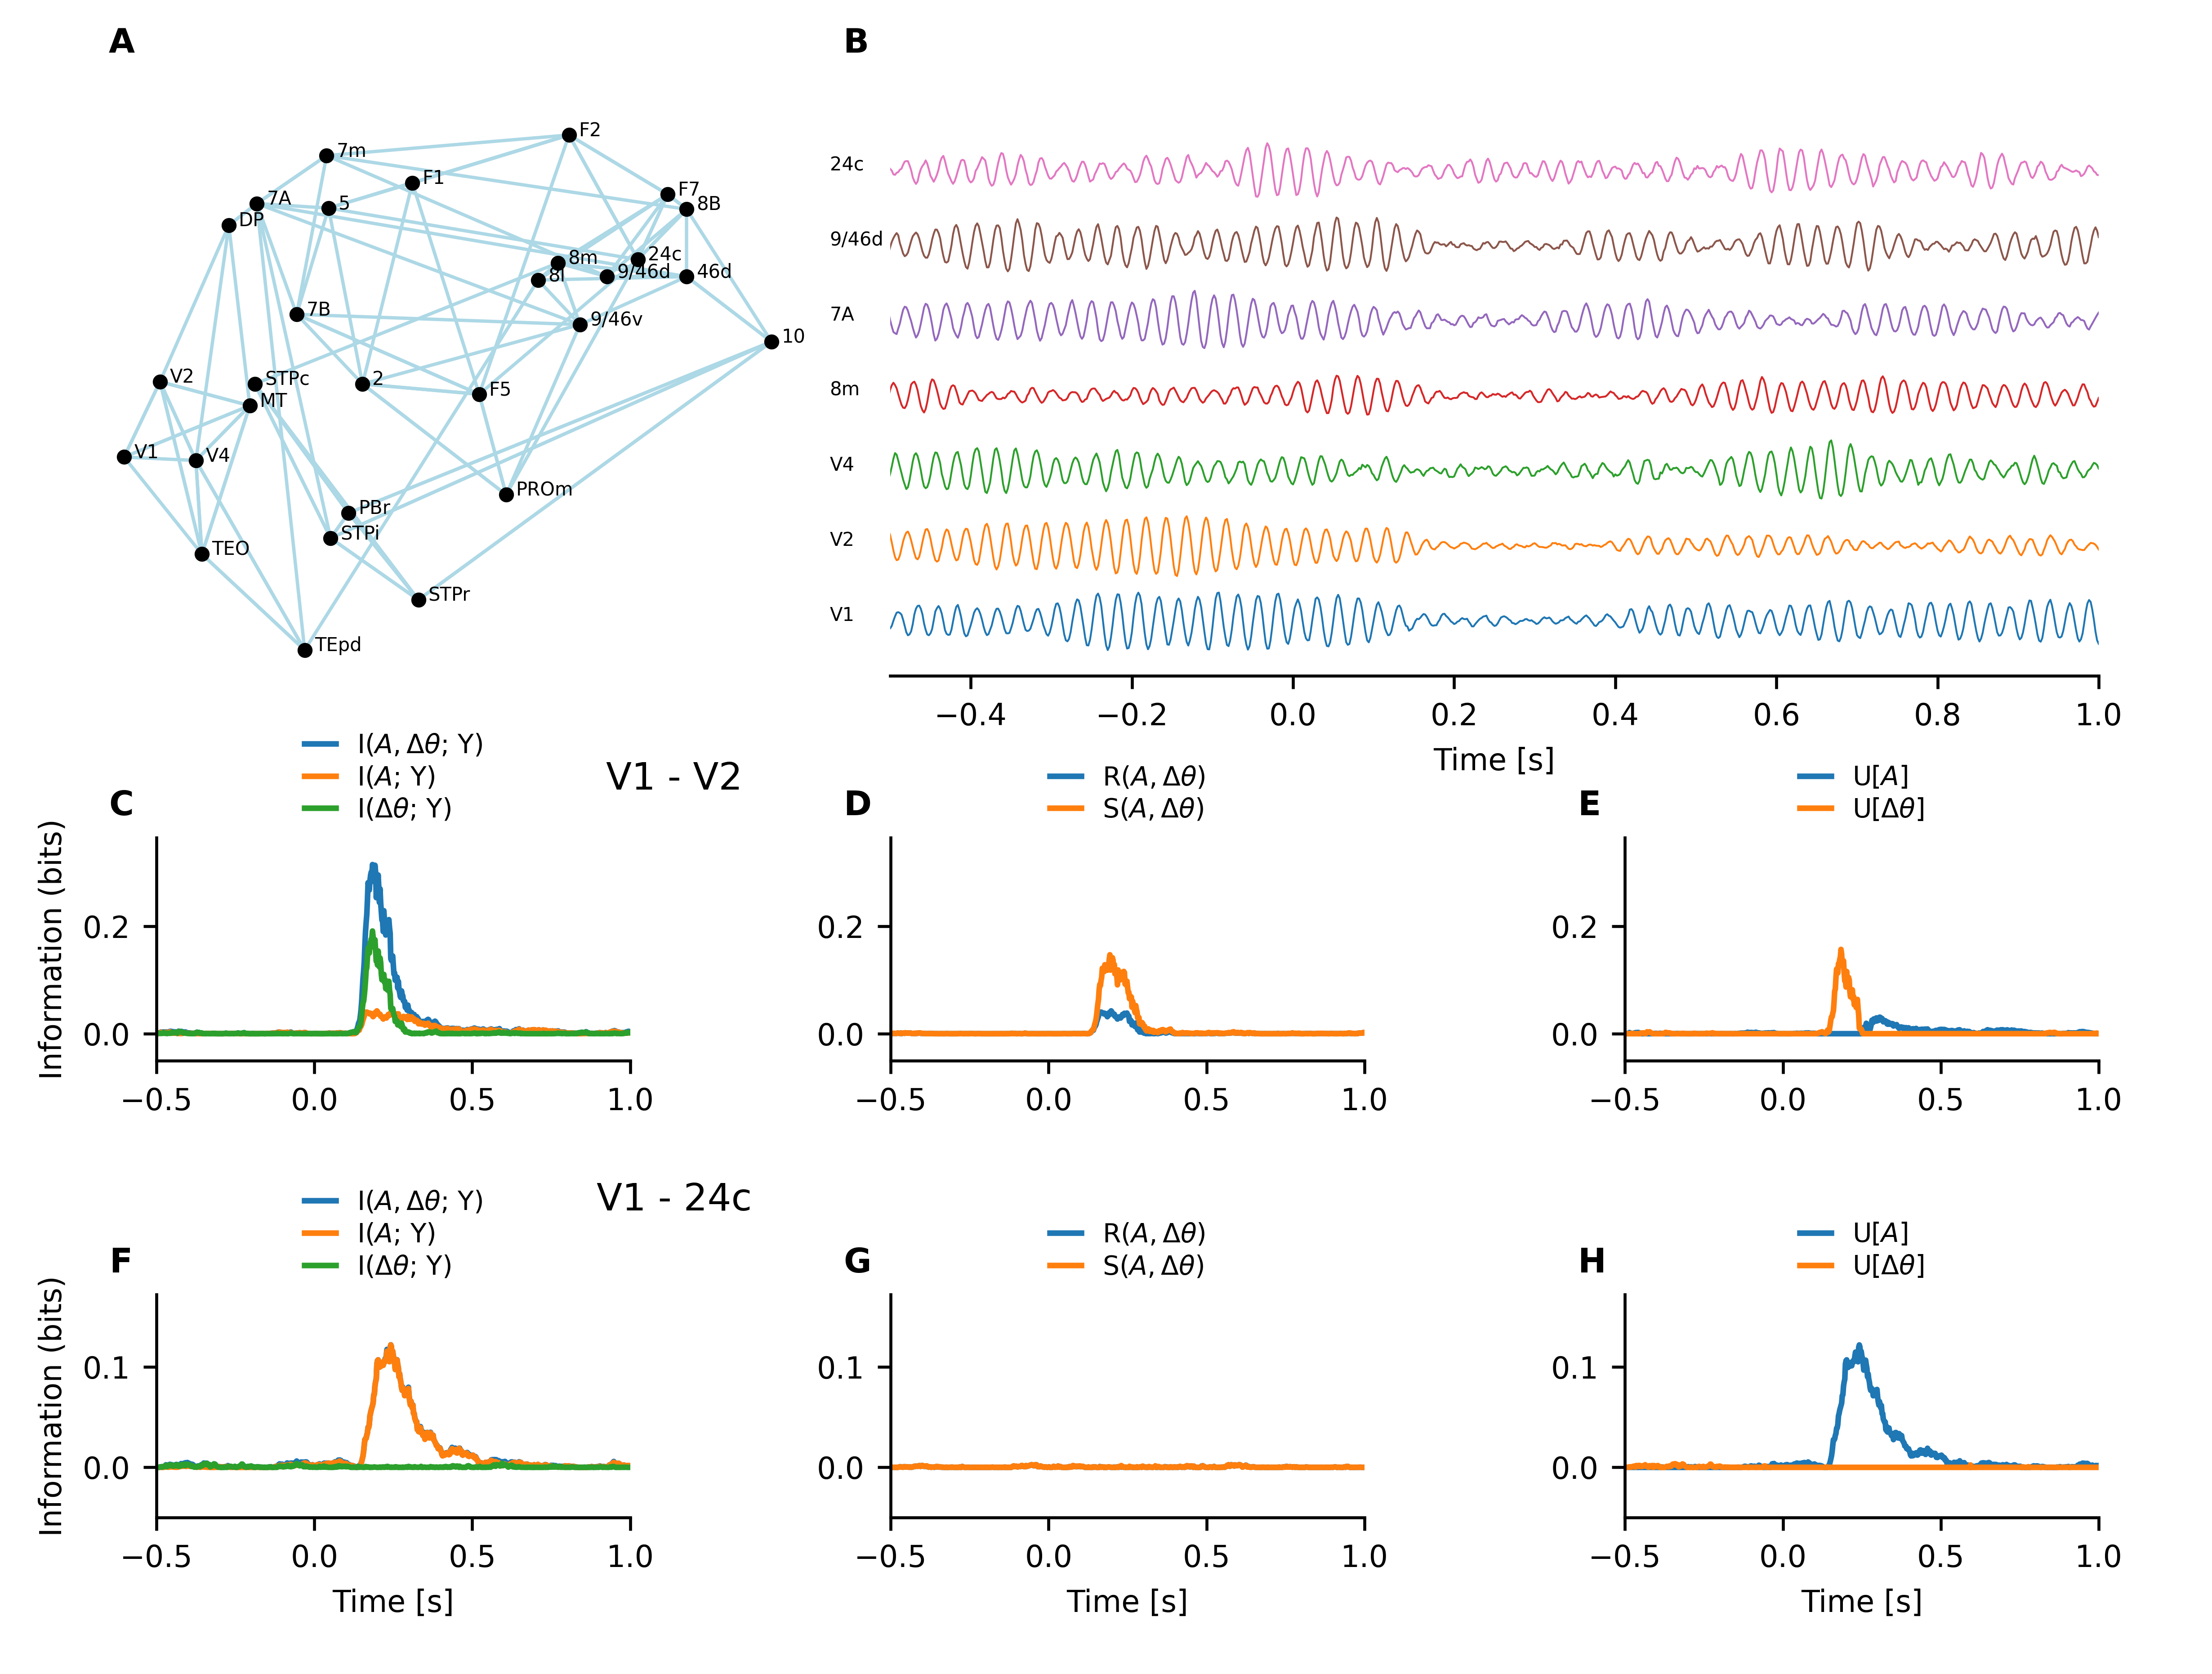

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 4 (Panels A–H only)
fig = plt.figure(figsize=(8.0, 6), dpi=600)

# Panel A - brain network graph (top-left)
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.03, right=0.36, bottom=0.60, top=0.95)

# Panel B - left edge aligned with Panel D (col 1 of gs3):
#   col1_left = 0.06 + (0.90/4.1)*1.55 ≈ 0.400
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.400, right=0.96, bottom=0.60, top=0.95)

# Panels C-H: 2 rows x 3 cols (bottom)
gs3 = fig.add_gridspec(
    nrows=2,
    ncols=3,
    left=0.06,
    right=0.96,
    bottom=0.08,
    top=0.50,
    hspace=1.05,
    wspace=0.55,
)

ax1 = plt.subplot(gs1[0])  # A
ax2 = plt.subplot(gs2[0])  # B
ax3 = plt.subplot(gs3[0, 0])  # C
ax4 = plt.subplot(gs3[0, 1])  # D
ax5 = plt.subplot(gs3[0, 2])  # E
ax6 = plt.subplot(gs3[1, 0])  # F
ax7 = plt.subplot(gs3[1, 1])  # G
ax8 = plt.subplot(gs3[1, 2])  # H

# Row labels for C-E and F-H
fig.text(0.30, 0.525, "V1 - V2", ha="center", va="bottom", fontsize=10)
fig.text(0.30, 0.265, "V1 - 24c", ha="center", va="bottom", fontsize=10)

# PANEL A — brain network graph
plt.sca(ax1)
mask = flnMat > np.quantile(flnMat, 0.87, axis=1)[:, None]
for n in range(29):
    for j in np.where(mask[n])[0]:
        x1, y1 = xy[n]
        x2, y2 = xy[j]
        plt.plot([x1, x2], [y1, y2], "lightblue", lw=0.9)
for pos, (x_, y_) in enumerate(xy):
    plt.plot(x_, y_, "ko", ms=3)
    plt.text(x_ + 10, y_ + 1, area_names[pos], fontsize=5)
ax1.yaxis.set_inverted(True)
plt.axis("off")

# PANEL B — oscillatory traces
plt.sca(ax2)
z_data = (data - data.mean("times")) / data.std("times")
rois = sel_area_names
for i, roi in enumerate(rois):
    plt.plot(z_data[-1].times, z_data[-1].values[i].real + (i * 5), lw=0.5)
    plt.text(-0.575, i * 5, roi, fontsize=5)
plt.xlim(-0.5, 1)
plt.xlabel("Time [s]")
ax2.set_yticks([])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(axis="y", left=False, labelleft=False)

# PANELS C–E and F–H
plot_mutual_info(ax3, ax4, ax5, 0, xlabel=False)
plot_mutual_info(ax6, ax7, ax8, -1)

# Panel letters
# xpos for A and B are chosen so their labels land at the same figure-x as C and D:
#   col_width = 0.90/4.1 ≈ 0.2195
#   label_C fig-x = 0.06 + (-0.10)*0.2195 = 0.0380  → xpos_A = (0.0380-0.03)/0.33 ≈  0.024
#   label_D fig-x = 0.400 + (-0.10)*0.2195 = 0.3780  → xpos_B = (0.3780-0.400)/0.56 ≈ -0.039
bg = plot.Background(visible=False)
plot.add_panel_letters(
    fig,
    axes=[ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8],
    fontsize=MEDIUM_SIZE,
    xpos=[0.024, -0.039, -0.10, -0.10, -0.10, -0.10, -0.10, -0.10],
    ypos=[1.1] * 8,
)

plt.savefig("../figures/Figure4.pdf", bbox_inches="tight")
plt.show()


Figure 4: Phase and amplitude interactions in realistic SL whole-brain model. (A) Structural connectivity derived from the dataset reported in Markov et al. (2014). Here we show it as a binary network with only the top four connections of each cortical area being drawn (FLN greater than the 87 percentile for each source area). (B) The real part of the (Real(Z)) time-series for the simulated SL whole-brain model for selected 9 cortical areas in one trial. The black time-series on the bottom show the global coupling dynamics g(t). The coupling strength g among nodes was transiently modulated from 0 to 0.4 ms according to g(t) = 8Y/(2π f ), where Y was the maximum coupling amplitude which was increased from 1 to 100 across trials (n = 1000). (C)
The time-series of the total mutual information between V1 and V2 carried by their joint amplitude A and
phase-difference ∆θ about the stimulus (blue curve). Only their amplitude interaction (orange curve), and
only their phase-difference (green). (D) The redundancy (blue curve) and synergy (orange curve) between
the joint amplitude and phase-difference concerning the stimulus. (E) The unique stimulus information
contained in the joint amplitude (orange curve), and only their phase-difference (green). (F-H) The same
as C-E but for areas V1 and 24C.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 5: higher-order phase interactions (2-plets and 3-plets)
fig = plt.figure(figsize=(6.0, 2), dpi=600)
gs = fig.add_gridspec(
    nrows=1, ncols=4,
    left=0.05, right=0.995,
    bottom=0.22, top=0.82,
    wspace=0.35,
)

ax1 = plt.subplot(gs[0, 0])  # A: Redundancy (2-plets)
ax2 = plt.subplot(gs[0, 1])  # B: Synergy (2-plets)
ax3 = plt.subplot(gs[0, 2])  # C: Redundancy (3-plets)
ax4 = plt.subplot(gs[0, 3])  # D: Synergy (3-plets)

# A — Redundancy (2-plets)
plt.sca(ax1)
plt.plot(data.times, red.T[:, sel_2plets], lw=0.9)
plt.title(labels_edges_2plets[0], fontsize=6)
[ax1.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("Redundancy (bits)", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax1.tick_params(labelsize=6)

# B — Synergy (2-plets)
plt.sca(ax2)
plt.plot(data.times, syn.T[:, sel_2plets], lw=0.9)
plt.title(labels_edges_2plets[0], fontsize=6)
[ax2.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("Synergy (bits)", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax2.tick_params(labelsize=6)

# C — Redundancy (3-plets)
plt.sca(ax3)
plt.plot(data.times, red3.T[:, sel_3plets], lw=0.9)
plt.title(labels_edges_3plets[0], fontsize=6)
[ax3.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("Redundancy (bits)", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax3.tick_params(labelsize=6)

# D — Synergy (3-plets)
plt.sca(ax4)
plt.plot(data.times, syn3.T[:, sel_3plets], lw=0.9)
plt.title(labels_edges_3plets[0], fontsize=6)
[ax4.spines[k].set_visible(False) for k in ["top", "right"]]
plt.ylabel("Synergy (bits)", fontsize=7)
plt.xlabel("Time [s]", fontsize=7)
plt.xlim(-0.5, 1)
ax4.tick_params(labelsize=6)

# panel letters A–D
for letter, ax in zip(["A", "B", "C", "D"], [ax1, ax2, ax3, ax4]):
    ax.text(-0.20, 1.08, letter, transform=ax.transAxes,
            fontsize=MEDIUM_SIZE, fontweight="bold")

plt.savefig("../figures/Figure5.pdf", bbox_inches="tight")
plt.show()


Figure 5: High-order interaction based on phased relations in the SL whole-brain model. High-order redundant (A) and synergistic (B) information encoded by pairs of edges via phase difference interactions. The curves shown are for the two disconnected edges (four nodes in total) with highest synergy and redundancy formed by the edges V2-V4
with 8m-9/45d. High-order redundant (C) and synergistic (D) information encoded by triplets of edges via phase difference interactions. Edges are V1-V2, V2-V4 and 8m-9/46d, thus containing 5 areas.